# Store로 장기 기억 관리하기
- 'Store'를 사용하여 'thread_id'가 달라져도 유지되는 장기 기억을 관리한다.

## 환경 변수 로드

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 모델 준비

In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4.1-mini')

## 장기 기억 추출 모델 정의

In [3]:
from pydantic import BaseModel, Field
from typing import Literal

class MemoryExraction(BaseModel):
    should_save:bool=Field(
        description='사용자의 발화에 장기 기억으로 저장할 만한 선호나 정보가 있으면 True'
    )
    category:Literal['food','travel','communicaton','profile','other'] = Field(
        description='저장할 기억의 방주'
    )
    memory:str = Field(
        description='장기 기억으로 저장할 내용을 한 문자으로 요약'
    )

memory_exractor = llm.with_structured_output(MemoryExraction)

## State 정의

In [4]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]
    memories:list[str]

## store에 저장된 기억을 읽는 함수

In [5]:
from langgraph.store.base import BaseStore

def get_user_memories(store:BaseStore,user_id:str) -> list[str]:
    """Store에서 특정 사용자의 장기 기억 목록을 조회한다."""
    # store는 namespace와 key를 기준으로 값을 저장한다.
    namespace = ("memories",user_id)
    items = store.search(namespace)

    memories = []
    for item in items:
        value = item.value
        if isinstance(value,dict) and 'memory' in value:
            memories.append(value['memory'])

    return memories

## 사용자 발화에서 장기 기억 저장하기

In [16]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

def save_memory_node(
        state:State,
        config:RunnableConfig,
        *,
        store:BaseStore
):
    """사용자 메세지에서 장기 기억으로 저장할 정보를 추출하고 store에 저장한다."""
    user_id = config['configurable']['user_id']
    messages = state['messages']
    last_message = messages[-1]

    # 마지막 메세지가 사용자 메세지가 아니면 저장 판단을 하지 않는다.
    if not isinstance(last_message, HumanMessage):
        memories = get_user_memories(store,user_id)
        return {'memories',memories}
    
    # 마지막 메세지가 사용자 메세지라면 장기 기억 저장이 필요한지 확인해서 저장한다.
    extraction = memory_exractor.invoke(
        [
            {
                'role':'system',
                'content':(
                    '사용자의 발화에서 앞으로의 대화나 추천에 계속 활용할 만한 개인 선호나 프로필 정보를 추출하세요.'
                    '일회성 질문, 단순 인사, 일반 지식 질문은 저장하지 마세요.'
                )
            },
            {
                'role':'user',
                'content':last_message.content
            }
        ]
    )

    if extraction.should_save:
        namespace = ('memories',user_id)
        existing = store.search(namespace)
        key = f'{extraction.category}_{len(existing)+1}'

        store.put(
            namespace,
            key,
            {
                'category':extraction.category,
                'memory':extraction.memory
            }
        )

    memories = get_user_memories(store,user_id)
    return {'memories': memories}

## 장기 기억을 반영해 답변 생성하기

In [8]:
def answer_node(state:State):
    """현재 메세지와 장기기억을 바탕으로 답변을 생성한다."""

    memories = state.get('memories',[])

    if memories:
        memory_text = '\n'.join(f'- {memory}' for memory in memories)
    else:
        memory_text = '저장된 장기 기억이 없습니다.'

    response = llm.invoke(
        [
            {
                'role':'system',
                'content':(
                    '당신은 사용자이 선호를 기억하고 자연스럽게 반영하는 assistant입니다.'
                    '아래 장기 기억이 있으면 답변에 참고하세요.'
                    f'[장기기억]\n{memory_text}\n'
                    '단, 사용자가 문지 않은 개인 정보를 과도하게 드러내지는 마세요'
                )
            },
            *state['messages']
        ]
    )

    return{'messages':[response]}

## 그래프 구성
1. 사용자 메세지에서 저장할 만한 장기 기억을 추출한다.
2. Store에 저장된 기억 목록을 state에 반영한다.
3. 장기 기억을 참고해 답변을 생성한다.

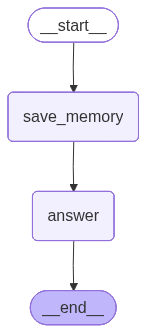

In [18]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

graph_builder = StateGraph(State)

graph_builder.add_node('save_memory',save_memory_node)
graph_builder.add_node('answer',answer_node)

graph_builder.add_edge(START,'save_memory')
graph_builder.add_edge('save_memory','answer')
graph_builder.add_edge('answer',END)

checkpointer = InMemorySaver()
store = InMemoryStore()

graph = graph_builder.compile(
    checkpointer=checkpointer,
    store=store
)

graph

## 첫 번째 대화방에서 사용자 선호 저장하기
- 'thread_id': 현재 대화방 구분
- 'user_id': 사용자 구분

In [19]:
config_user1_thread1 = {
    'configurable' : {
        'user_id':'user_1',
        'thread_id':'thread_1'
    }
}

result = graph.invoke({
    'messages': [HumanMessage(content='나는 매운 음식을 잘 못 먹고, 채식 옵션이 있는 식당을 선호해')]
    },
    config=config_user1_thread1
)

print(result['messages'][-1].content)

네, 매운 음식을 잘 못 드시고 채식 옵션이 있는 식당을 선호하시는군요. 앞으로 음식 추천이나 식당 안내할 때 이 부분을 꼭 반영해서 알려드릴게요. 도움이 필요하시면 언제든 말씀해 주세요!


## Store에 저장된 장기 기억 확인하기

In [20]:
memories = store.search(('memories','user_1'))

for item in memories:
    print('key : ',item.key)
    print('value : ',item.value)
    print()

key :  food_1
value :  {'category': 'food', 'memory': '사용자는 매운 음식을 잘 못 먹으며, 채식 옵션이 있는 식당을 선호함'}



## 다른 대화방에서 같은 사용자 기억 조회하기
- 동일 'user_id'를 사용하되 'thread_id'는 변경해서 테스트한다.

In [21]:
config_user1_thread2 = {
    'configurable':{
        'user_id':"user_1",
        "thread_id":'thread_2'
    }
}

result = graph.invoke(
    {
        'messages':[HumanMessage(content='오늘 저녁 식당을 추천해줘')]
    },
    config=config_user1_thread2
)

print(result['messages'][-1].content)

매운 음식을 잘 못 드시고 채식 옵션을 선호하신다고 기억하고 있어요. 그래서 그런 취향에 잘 맞는 식당을 추천해드릴게요.

혹시 어느 지역에서 식사하실 예정인지 알려주실 수 있나요? 그 지역을 알려주시면 더 구체적으로 추천해드릴게요!


## 다른 사용자와 Store 기억이 분리되는지 확인
- 'user_id'와 'thread_id'를 모두 변경해서 테스트 한다.

In [22]:
config_user2_thread3 = {
    'configurable':{
        'user_id':"user_2",
        "thread_id":'thread_3'
    }
}

result = graph.invoke(
    {
        'messages':[HumanMessage(content='오늘 저녁 식당을 추천해줘')]
    },
    config=config_user2_thread3
)

print(result['messages'][-1].content)

안녕하세요! 오늘 어떤 스타일의 음식을 원하시나요? 한식, 중식, 양식, 일식 등 선호하는 종류나 특별히 먹고 싶은 메뉴가 있으면 알려주세요. 그리고 식당 위치(예: 동네나 지역)도 알려주시면 더 잘 추천해드릴 수 있어요!


## 여행 선호도 추가로 저장하기

In [23]:
result = graph.invoke(
    {
        'messages':[HumanMessage(content='여행 일정은 너무 이른 아침부터 시작하지 않았으면 좋겠고, 데중교통으로 이동하기 쉬운 코스를 좋아해.')]
    },
    config=config_user1_thread2
)

print(result['messages'][-1].content)

여행 일정과 이동 선호도도 잘 기억하고 있어요! 저녁 식당 추천을 위해서 어느 지역인지 알려주시면, 대중교통 접근이 쉽고 채식 메뉴가 있는 식당 중에서 맞춤 추천해드릴게요. 어느 지역에서 식사하실 계획인가요?


In [24]:
memories = store.search(('memories','user_1'))

for item in memories:
    print('key : ',item.key)
    print('value : ',item.value)
    print()

key :  food_1
value :  {'category': 'food', 'memory': '사용자는 매운 음식을 잘 못 먹으며, 채식 옵션이 있는 식당을 선호함'}

key :  travel_2
value :  {'category': 'travel', 'memory': '사용자는 여행 일정을 너무 이른 아침부터 시작하지 않기를 원하며, 대중교통으로 이동하기 쉬운 코스를 선호한다.'}

